In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [3]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [7]:
X = df.drop("target", axis=1)
y = df["target"]

scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
def create_model(lr):
    model = Sequential()
    model.add(Dense(32,activation='relu',input_shape=(13,)))
    model.add(Dense(16,activation='relu'))
    model.add(Dense(8,activation='relu'))
    model.add(Dense(1,activation='sigmoid'))
    optimizer = Adam( learning_rate=lr)
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [10]:
learning_rates = [0.1,0.01,0.001,0.0001]

results=[]
for lr in learning_rates:
    model=create_model(lr)
    history=model.fit(X_train,y_train,epochs=20, validation_split=0.2,verbose=0
    )

    loss,acc=model.evaluate(X_test,y_test,verbose=0)
    results.append([lr,acc])

C:\Users\Akshada\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]

results = []
for lr in learning_rates:
    model = create_model(lr)
    history = model.fit(X_train,y_train,epochs=20,validation_split=0.2,verbose=0)

    loss, acc = model.evaluate(X_test,y_test,verbose=0)
    results.append([lr, acc])
results = pd.DataFrame(results,
    columns=["Learning Rate", "Accuracy"])

print(results)

C:\Users\Akshada\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Learning Rate  Accuracy
0         0.1000  0.839024
1         0.0100  0.912195
2         0.0010  0.863415
3         0.0001  0.707317


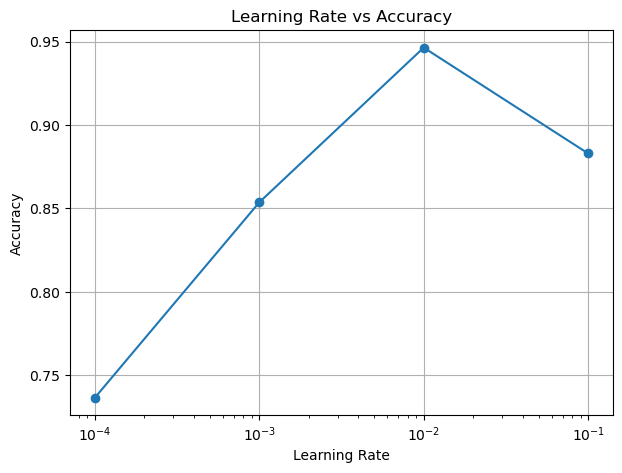

In [14]:
plt.figure(figsize=(7,5))
plt.plot(
    results["Learning Rate"],
    results["Accuracy"],
    marker='o'
)
plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Learning Rate vs Accuracy")
plt.grid()
plt.show()

In [28]:
epochs = [5, 10, 20, 50]
epoch_results = []

for ep in epochs:
    model = create_model(0.001)
    history = model.fit( X_train, y_train,epochs=ep,validation_split=0.2,verbose=0)
    loss, acc = model.evaluate(X_test,y_test,verbose=0)

    epoch_results.append([ep, acc])
epoch_results = pd.DataFrame(epoch_results,
    columns=["Epochs", "Accuracy"]
)

print(epoch_results)

C:\Users\Akshada\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Epochs  Accuracy
0       5  0.760976
1      10  0.824390
2      20  0.863415
3      50  0.931707


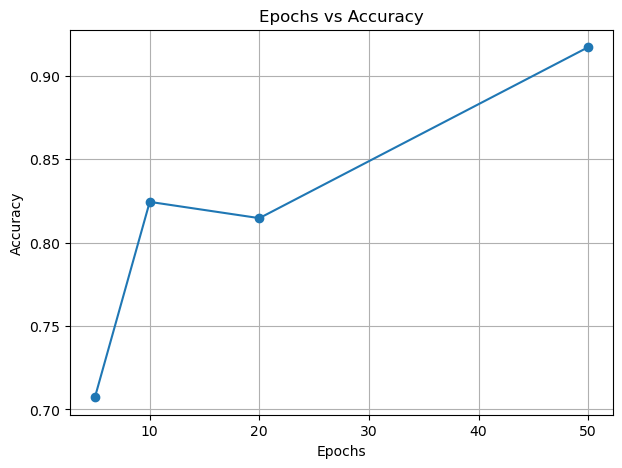

In [24]:
plt.figure(figsize=(7,5))
plt.plot(
    epoch_results["Epochs"],
    epoch_results["Accuracy"],
    marker='o'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Epochs vs Accuracy")
plt.grid()
plt.show()

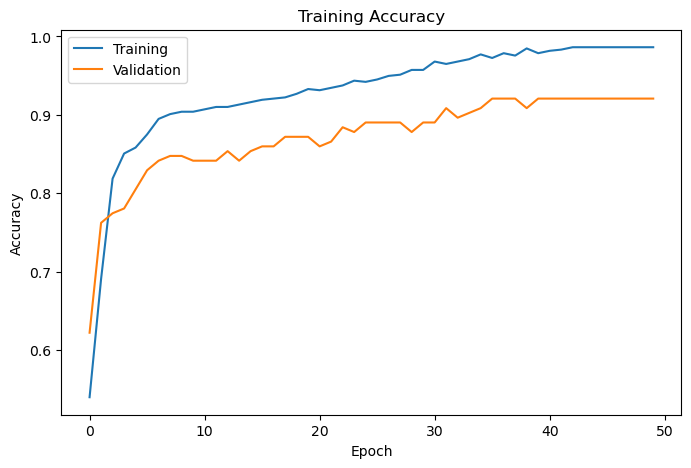

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(["Training","Validation"])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

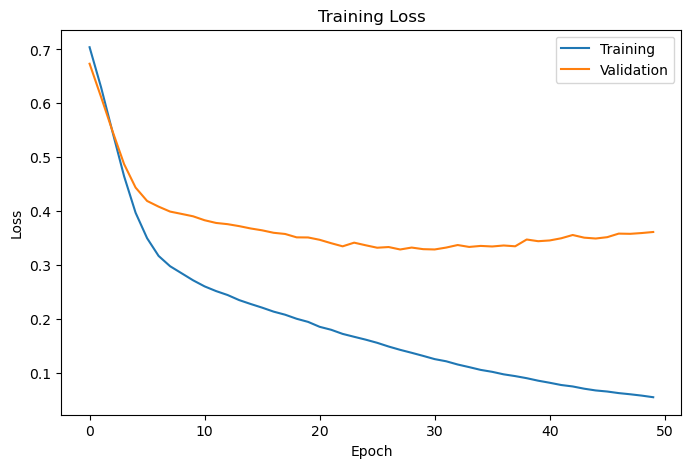

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(["Training","Validation"])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()